# 10c — Externalities and Pigouvian taxation

Covers `chap10_externality1.m`, `externality2a.m`, `externality2b.m`,
and `externality3.m`: the textbook supply/demand deadweight-loss diagram
from a quantity restriction, the externality/social-marginal-cost DWL
diagram (consumer/producer surplus, external cost, overproduction), the
same model's numeric worked example at three quantities, and the
Pigouvian-tax-correction diagram showing how an emissions tax set equal
to marginal external cost at the social optimum restores efficiency.
All four scripts are self-contained (hardcoded illustrative demand/cost
curves, no external data).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

color_blue = "#1f77b4"
color_green = "#2ca02c"
color_red = "#d62728"
color_teal = "#17becf"
color_violet = "#9467bd"
color_black = "#000000"


## 1. Market equilibrium and deadweight loss from a quantity restriction (`chap10_externality1.m`)

Standard supply/demand diagram: consumer and producer surplus at the
market equilibrium $(q^{\star}, p^{\star})$, then the deadweight-loss
triangle that opens up if quantity is restricted to $q' < q^{\star}$
(illustrative curve/point values, hand-set to match the source
script).

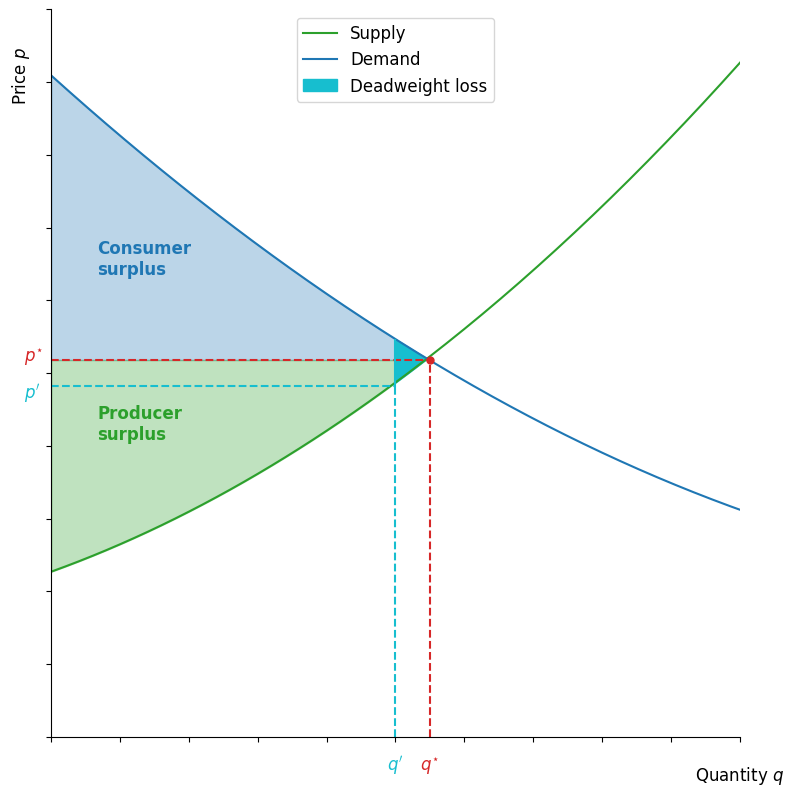

In [2]:
q = np.arange(0, 20.01, 0.1)
demand = 20 - 1.25 * q + 0.025 * q**2
supply = 5 + 0.5 * q + 0.035 * q**2
q_star, p_star = 8.25, 11.4
q_prime, p_prime, p_prime2 = 7.5, 10.6, 12.0

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(q, supply, color=color_green, lw=1.5)
ax.plot(q, demand, color=color_blue, lw=1.5)

cnd = q <= q_star
ax.fill_between(q[cnd], demand[cnd], p_star, color=color_blue, alpha=0.30)
ax.fill_between(q[cnd], supply[cnd], p_star, color=color_green, alpha=0.30)
ax.text(1.0, 14, "Consumer\nsurplus", color=color_blue, fontsize=12, fontweight="bold")
ax.text(1.0, 9, "Producer\nsurplus", color=color_green, fontsize=12, fontweight="bold")

ax.plot([0, q_star], [p_star, p_star], "--", color=color_red, lw=1.5)
ax.plot([q_star, q_star], [0, p_star], "--", color=color_red, lw=1.5)
ax.scatter([q_star], [p_star], s=25, color=color_red, zorder=5)
ax.text(q_star, -1, "$q^{\star}$", color=color_red, fontsize=12, ha="center")
ax.text(-0.6, p_star + 0.1, "$p^{\star}$", color=color_red, fontsize=12, va="center")

ax.plot([0, q_prime], [p_prime, p_prime], "--", color=color_teal, lw=1.5)
ax.plot([q_prime, q_prime], [0, p_prime], "--", color=color_teal, lw=1.5)
ax.plot([q_prime, q_prime], [p_prime, p_prime2], color=color_teal, lw=1.5)
ax.text(q_prime, -1, "$q'$", color=color_teal, fontsize=12, ha="center")
ax.text(-0.6, p_prime - 0.2, "$p'$", color=color_teal, fontsize=12, va="center")

cnd = (q >= q_prime) & (q <= q_star)
dwl = ax.fill_between(q[cnd], demand[cnd], supply[cnd], color=color_teal, alpha=1.0)

ax.set_xlim(0, 15)
ax.set_ylim(0, 22)
ax.set_xticks(np.linspace(0, 15, 11))
ax.set_yticks(np.linspace(0, 22, 11))
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.spines["left"].set_position("zero")
ax.spines["bottom"].set_position("zero")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# Axis titles placed as free-floating text (matching the source's explicit
# label Position offsets) rather than via set_xlabel/set_ylabel, since with
# both spines pinned to the origin the default label placement collides
# with the q*/p*/q'/p' annotations near the origin.
ax.text(15, -1.3, "Quantity $q$", fontsize=12, ha="center")
ax.text(-0.9, 20, "Price $p$", fontsize=12, va="center", rotation=90)
ax.legend([ax.lines[0], ax.lines[1], dwl], ["Supply", "Demand", "Deadweight loss"],
          fontsize=12, loc="upper center")
plt.tight_layout()
plt.show()

## 2. Externality and the overproduction deadweight loss (`chap10_externality2a.m`)

Private marginal benefit (PMB, demand) and private marginal cost (PMC,
supply) determine the unregulated market equilibrium at $q_1=10$ (point
A/B). Adding the external marginal cost (EMC) gives the true social
marginal cost $SMC = PMC + EMC$; the social optimum is where $PMB=SMC$,
at $q_2=6$ (point C). The market overproduces by $q_1-q_2$, and the
shaded red triangle is the resulting deadweight loss.

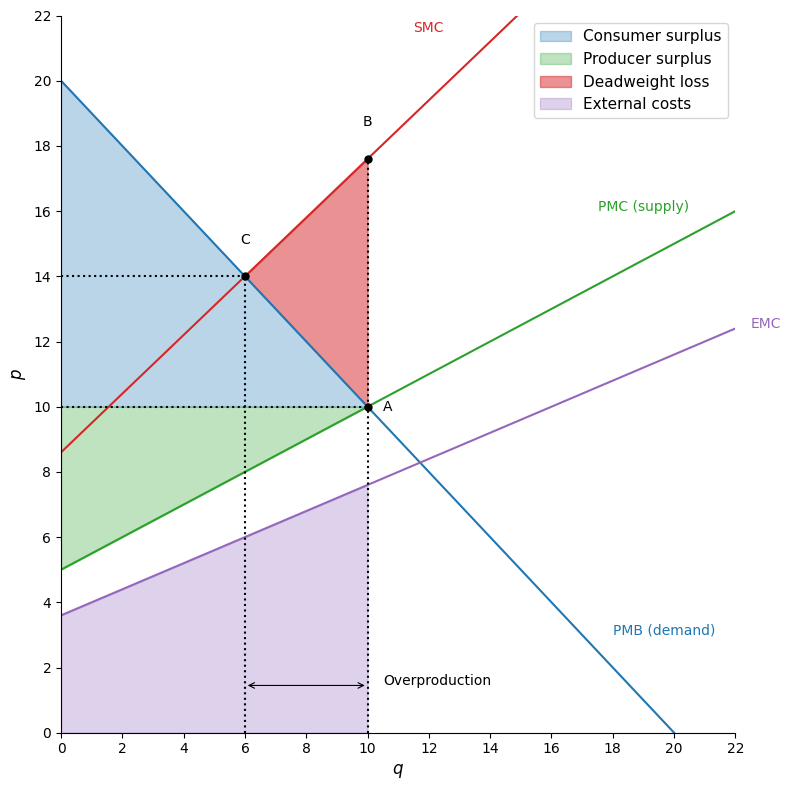

In [3]:
q2a = np.arange(0, 22.01, 0.5)
PMB = 20 - q2a
PMC = 5 + 0.5 * q2a
EMC = 3.6 + 0.4 * q2a
SMC = PMC + EMC

q1, q2 = 10, 6
PMC_q1 = 5 + 0.5 * q1
p1 = PMC_q1
SMC_q1 = 8.6 + 0.9 * q1
p1b = SMC_q1
SMC_q2 = 8.6 + 0.9 * q2
p2 = SMC_q2

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(q2a, PMB, color=color_blue, lw=1.5)
ax.plot(q2a, PMC, color=color_green, lw=1.5)
ax.plot(q2a, SMC, color=color_red, lw=1.5)
ax.plot(q2a, EMC, color=color_violet, lw=1.5)

ax.plot([0, q1], [PMC_q1, PMC_q1], ":", color=color_black, lw=1.5)
ax.plot([q1, q1], [0, SMC_q1], ":", color=color_black, lw=1.5)
ax.plot([q2, q2], [0, SMC_q2], ":", color=color_black, lw=1.5)
ax.plot([0, q2], [SMC_q2, SMC_q2], ":", color=color_black, lw=1.5)

cnd = q2a <= q1
cs = ax.fill_between(q2a[cnd], PMB[cnd], PMC_q1, color=color_blue, alpha=0.30)
ps = ax.fill_between(q2a[cnd], PMC[cnd], PMC_q1, color=color_green, alpha=0.30)
ec = ax.fill_between(q2a[cnd], EMC[cnd], 0, color=color_violet, alpha=0.30)

cnd = (q2a >= q2) & (q2a <= q1)
dwl = ax.fill_between(q2a[cnd], PMB[cnd], SMC[cnd], color=color_red, alpha=0.50)

ax.scatter([q1, q1, q2], [p1, p1b, p2], s=25, color=color_black, zorder=5)
ax.text(q1 + 0.5, p1, "A", fontsize=10, va="center")
ax.text(q1, p1b + 1.0, "B", fontsize=10, ha="center")
ax.text(q2, p2 + 1.0, "C", fontsize=10, ha="center")
ax.text(q1 + 0.5, 1.45, "Overproduction", fontsize=10)
ax.text(22.5, 12.4, "EMC", color=color_violet, fontsize=10)
ax.text(20.5, 16, "PMC (supply)", color=color_green, fontsize=10, ha="right")
ax.text(18, 3, "PMB (demand)", color=color_blue, fontsize=10)
ax.text(11.5, 21.5, "SMC", color=color_red, fontsize=10)
ax.annotate("", xy=(q1, 1.45), xytext=(q2, 1.45),
            arrowprops=dict(arrowstyle="<->", lw=0.8))

ax.set_xlim(0, 22)
ax.set_ylim(0, 22)
ax.set_xticks(np.arange(0, 23, 2))
ax.set_yticks(np.arange(0, 23, 2))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlabel("$q$", fontsize=12)
ax.set_ylabel("$p$", fontsize=12)
ax.legend([cs, ps, dwl, ec], ["Consumer surplus", "Producer surplus", "Deadweight loss", "External costs"],
          fontsize=11, loc="upper right")
plt.tight_layout()
plt.show()

## 3. Numeric worked example (`chap10_externality2b.m`)

The same PMB/PMC/EMC model evaluated at three quantities ($q=10, 9, 6$)
using the total (integrated) benefit/cost/external-cost functions
$PB(q)$, $PC(q)$, $EC(q)$ (whose derivatives are $PMB$, $PMC$, $EMC$
above) — reproducing the source script's printed diagnostic output.
Net social benefit $PB - PC - EC$ is maximized at $q=6$, confirming the
social optimum found graphically in Section 2.

In [4]:
PB = lambda q: 5 + 20 * q - 0.5 * q**2
PC = lambda q: 1 + 5 * q + 0.25 * q**2
EC = lambda q: 3.6 * q + 0.2 * q**2
PMB_f = lambda q: 20 - q
PMC_f = lambda q: 5 + 0.5 * q
EMC_f = lambda q: 3.6 + 0.4 * q

rows = []
for qv in [10, 9, 6]:
    rows.append({
        "q": qv,
        "PB(q)": PB(qv), "PC(q)": PC(qv), "EC(q)": EC(qv),
        "Net = PB-PC-EC": PB(qv) - PC(qv) - EC(qv),
        "PMB(q)": PMB_f(qv), "PMC(q)": PMC_f(qv), "EMC(q)": EMC_f(qv),
    })
pd.DataFrame(rows).set_index("q").round(2)

,PB(q),PC(q),EC(q),Net = PB-PC-EC,PMB(q),PMC(q),EMC(q)
q,,,,,,,
10,155.0,76.00,56.0,23.00,10,10.0,7.6
9,144.5,66.25,48.6,29.65,11,9.5,7.2
6,107.0,40.00,28.8,38.20,14,8.0,6.0


## 4. The Pigouvian tax correction (`chap10_externality3.m`)

Setting an emissions tax equal to the marginal external cost evaluated
at the social optimum, $\mathrm{Tax}=EMC(q_2^{\star})$, shifts the
private supply curve from $PMC$ up to $PMC' = PMC+\mathrm{Tax}$. The
new (taxed) market equilibrium, where $PMB=PMC'$, lands exactly at the
socially optimal quantity $q_2=6$ found in Section 2 — the tax fully
internalizes the externality.

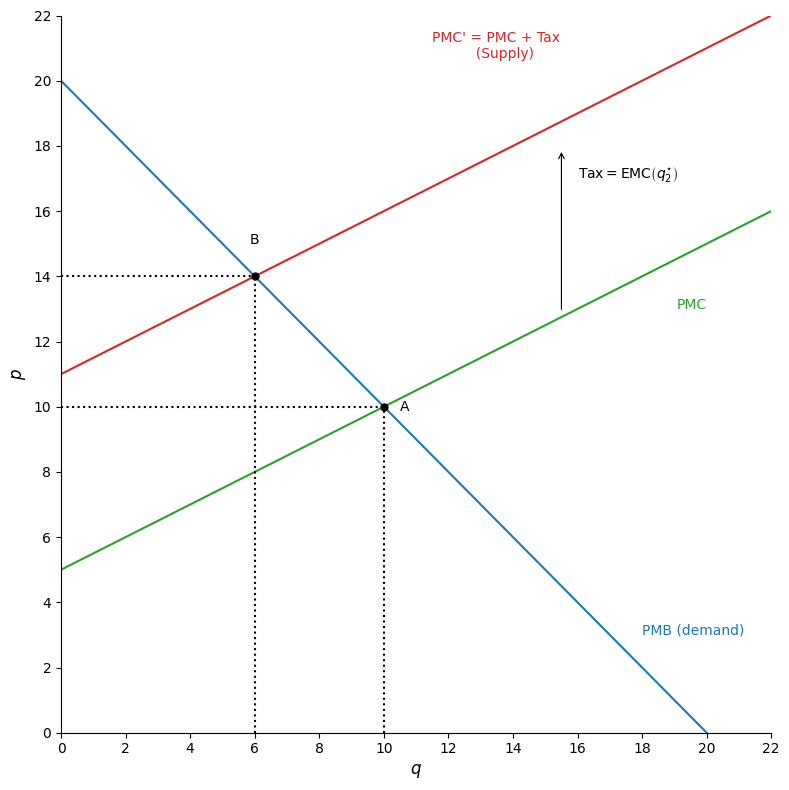

In [5]:
q3 = np.arange(0, 22.01, 0.5)
PMB3 = 20 - q3
PMC3 = 5 + 0.5 * q3

q1, q2 = 10, 6
PMC_q1 = 5 + 0.5 * q1
p1 = PMC_q1
SMC_q2 = 8.6 + 0.9 * q2
p2 = SMC_q2
EMC_q2 = 3.6 + 0.4 * q2
tax = EMC_q2
SMC_tax = PMC3 + tax

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(q3, PMB3, color=color_blue, lw=1.5)
ax.plot(q3, PMC3, color=color_green, lw=1.5)
ax.plot(q3, SMC_tax, color=color_red, lw=1.5)

ax.plot([0, q1], [PMC_q1, PMC_q1], ":", color=color_black, lw=1.5)
ax.plot([q1, q1], [0, PMC_q1], ":", color=color_black, lw=1.5)
ax.plot([q2, q2], [0, SMC_q2], ":", color=color_black, lw=1.5)
ax.plot([0, q2], [SMC_q2, SMC_q2], ":", color=color_black, lw=1.5)

ax.scatter([q1, q2], [p1, p2], s=25, color=color_black, zorder=5)
ax.text(q1 + 0.5, p1, "A", fontsize=10, va="center")
ax.text(q2, p2 + 1.0, "B", fontsize=10, ha="center")
ax.text(20, 13.0, "PMC", color=color_green, fontsize=10, ha="right")
ax.text(18, 3, "PMB (demand)", color=color_blue, fontsize=10)
ax.text(11.5, 20.7, "PMC' = PMC + Tax\n          (Supply)", color=color_red, fontsize=10)
ax.text(16.0, 17.0, r"$\mathrm{Tax} = \mathrm{EMC}\left(q^{\star}_2\right)$",
        color=color_black, fontsize=10)
ax.annotate("", xy=(15.5, 17.9), xytext=(15.5, 12.9),
            arrowprops=dict(arrowstyle="->", lw=0.8))

ax.set_xlim(0, 22)
ax.set_ylim(0, 22)
ax.set_xticks(np.arange(0, 23, 2))
ax.set_yticks(np.arange(0, 23, 2))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlabel("$q$", fontsize=12)
ax.set_ylabel("$p$", fontsize=12)
plt.tight_layout()
plt.show()